# Loading Raw Data In and Importing Libraries

In [40]:
import pandas as pd
import networkx as nx
import os
import pathlib
import re
from scipy import stats
import itertools
import matplotlib.pyplot as plt

def list_files_in_directory(directory_path:str) -> list[str]:
    """returns file paths in raw_data/"""
    
    files_list = []
    for entry in os.listdir(directory_path):
        full_path = os.path.join(directory_path,entry)
        if os.path.isfile(full_path):
            files_list.append(full_path)
    return files_list

def create_data_dict(path_li:list[str]) -> dict[str,pd.DataFrame]:
    """ makes a dictionary containing dataframes """
    
    data_dict = {}
    for path in path_li:
        file_name = pathlib.PurePath(path).name.split('.')[0]
        df = pd.read_csv(path)
        data_dict[file_name] = df
    
    return data_dict

# loading all data in raw_data/
DATA_DIR = os.path.join(os.getcwd(),'raw_data')
PATH_LI = list_files_in_directory(DATA_DIR)
DATA_DICT = create_data_dict(PATH_LI)
# output directory that stores data for visualizations
VIS_DIR = os.path.join(os.getcwd(),'visual_data')
os.makedirs(VIS_DIR,exist_ok=True)

# splitting data into separate dataframes
medals = DATA_DICT['olympic_medals']
results = DATA_DICT['olympic_results']
athletes = DATA_DICT['olympic_athletes']
hosts = DATA_DICT['olympic_hosts']
uscities = DATA_DICT['uscities']
athlete_profiles = DATA_DICT['athlete_profiles']

# Medal Winning Athlete Biographic Modeling
Using biographical details regarding team USA athletes, we construct a network graph of associated features. This analysis is to help us determine the importance of these features when it comes to winning medals.

In [41]:

## cleaning athlete_profiles ##
# Dropping unsuccessful scrapes
usa_athletes = DATA_DICT['athlete_profiles'].copy()
remove_unknown_str = "hometown != 'Unknown' and height != 'Unknown' and age != 'Unknown' and education != 'Unknown'"
usa_athletes = usa_athletes.query(remove_unknown_str).copy()
percent_kept = (len(usa_athletes) / len(DATA_DICT['athlete_profiles'])) * 100
# print(f"Percentage of athletes kept after removing 'Unknown' values: {percent_kept:.2f}%")

# Extracting city and state from hometown
def extract_city_state(hometown:str) -> tuple[str, str]:
    """Extracts city and state from a hometown string."""
    match = re.match(r"^(.*),\s*([A-Z]{2})$", hometown)
    if match:
        city = match.group(1).strip()
        state = match.group(2).strip()
        return city, state
    else:
        # Look up the city in uscities to find the state
        city_match = uscities[uscities['city'].str.lower() == hometown.strip().lower()]
        if not city_match.empty:
            return hometown.strip(), city_match.iloc[0]['state_id']
        return None, None

usa_athletes[['city', 'state']] = pd.DataFrame(
    usa_athletes['hometown'].apply(extract_city_state).tolist(),
    index=usa_athletes.index
 )

# Changing height to decimal feet
def parse_height_to_feet(height_str:str) -> float:
    """Converts a height string like 5'6\" into decimal feet."""
    match = re.match(r"^\s*(\d+)'\s*(\d+)\"\s*$", str(height_str))
    if not match:
        return None
    feet = int(match.group(1))
    inches = int(match.group(2))
    return feet + (inches / 12)

usa_athletes['height'] = usa_athletes['height'].apply(parse_height_to_feet).astype(float)

# changing age to int and making deceased a binary column
def parse_age_and_deceased(age_str:str) -> tuple[int, int]:
    """Extracts integer age and deceased flag from age text."""
    age_text = str(age_str)
    deceased = 1 if re.search(r"died", age_text, flags=re.IGNORECASE) else 0
    age_match = re.search(r"(\d+)", age_text)
    age_value = int(age_match.group(1)) if age_match else None
    return age_value, deceased

age_parsed = usa_athletes['age'].apply(parse_age_and_deceased)
usa_athletes['age'] = [value[0] for value in age_parsed]
usa_athletes['deceased'] = [value[1] for value in age_parsed]
usa_athletes['age'] = usa_athletes['age'].astype('Int64')
usa_athletes

# merging with medal data and keeping relevant columns
athlete_bio_medals = pd.merge(usa_athletes,
                            medals,
                              on='athlete_full_name',
                              how='inner')
bio_medal_columns = ['athlete_full_name', 'age', 'deceased', 'height', 
                     'city', 'state', 'medal_type','event_title']
athlete_bio_medals = athlete_bio_medals[bio_medal_columns]
display(athlete_bio_medals.head())

# storing merged data for visualizations
athlete_bio_medals.to_csv(os.path.join(VIS_DIR,'athlete_bio_medals.csv'),index=False)

# generating groupings for edges of graph
rank_weights = {'GOLD': 3, 'SILVER': 2, 'BRONZE': 1}
state_g = nx.Graph()
for name, group in athlete_bio_medals.groupby(by=['state']):

    group = group.copy()
    group.loc[:, 'medal_weight'] = group['medal_type'].map(rank_weights)

    events_weights_df = group[['event_title', 'medal_weight']].drop_duplicates()
    events_li = list(group['event_title'].unique())
    event_edges = list(itertools.combinations(events_li,2))
    edge_df = pd.DataFrame(event_edges, columns=['event1', 'event2'])
    event1_merged_df = pd.merge(edge_df, events_weights_df, left_on='event1', right_on='event_title')
    event2_merged_df = pd.merge(edge_df, events_weights_df, left_on='event2', right_on='event_title')
    full_edge_df = pd.merge(event1_merged_df, event2_merged_df, on=['event1', 'event2'], suffixes=('_1', '_2'))
    
    # summing medal weights for each edge
    full_edge_df['weight'] = full_edge_df['medal_weight_1'] + full_edge_df['medal_weight_2']
    full_edge_df = full_edge_df[['event_title_1', 'event_title_2', 'weight']]
    full_edge_df = full_edge_df.groupby(['event_title_1', 'event_title_2']).sum().reset_index()

    # skipping over wins with no connections to other events
    if not full_edge_df.empty:
        edges_weights = list(full_edge_df.itertuples(index=False, name=None))
        state_g.add_weighted_edges_from(edges_weights)


,athlete_full_name,age,deceased,height,city,state,medal_type,event_title
0,Alex FERREIRA,31,0,5.75,Aspen,CO,BRONZE,Men's Freeski Halfpipe
1,Alex FERREIRA,31,0,5.75,Aspen,CO,SILVER,Men’s Ski Halfpipe
2,Chloe KIM,25,0,5.25,Torrance,CA,GOLD,Women's Snowboard Halfpipe
3,Chloe KIM,25,0,5.25,Torrance,CA,GOLD,Ladies’ Halfpipe
4,Nick BAUMGARTNER,44,0,6.00,Iron River,MI,GOLD,Mixed Team Snowboard Cross


# Event-to-Event Graph Measures

In [42]:
eigen_centrality_se = pd.Series(nx.eigenvector_centrality(state_g, weight='weight'))
betweenness_centrality_se = pd.Series(nx.betweenness_centrality(state_g, weight='weight'))


eigen_centrality_se.sort_values(ascending=False).head(10)
network_measures_df = pd.concat([eigen_centrality_se,
                                 betweenness_centrality_se],
                                 axis=1,
                                 keys=['eigenvector_centrality',
                                       'betweenness_centrality'])
display(network_measures_df.sort_values(by='eigenvector_centrality',
                                        ascending=False).head(5))
display(network_measures_df.sort_values(by='betweenness_centrality',
                                        ascending=False).head(5))

# outputting network measures to csv for visualization
network_measures_df.to_csv(os.path.join(VIS_DIR,'network_measures.csv'),index=True)

,eigenvector_centrality,betweenness_centrality
Beach volleyball women,0.335032,0.000000
200m breaststroke women,0.335032,0.000000
decathlon men,0.265591,0.000000
110m hurdles men,0.214535,0.066858
Doubles mixed,0.214315,0.000000


,eigenvector_centrality,betweenness_centrality
100m breaststroke women,0.127249,0.206520
100m backstroke women,0.156536,0.186436
400m freestyle men,0.094839,0.150492
Individual women,0.125092,0.140990
two-woman women,0.004757,0.076395


# Event-to-Event Graph Visualization
Few key things to take away from the graph.
- Each node represents an event that one team USA athlete received a medal across all olympic games.
    - The lighter the node, the more states have won medals in the same event
    - the Larger the node, the more important this event is to team USA's collective medal wins.
- Each edge is the represents whether 1 state won a medal in 2 different events.
    - Shorter the edge, the higher the medal values won

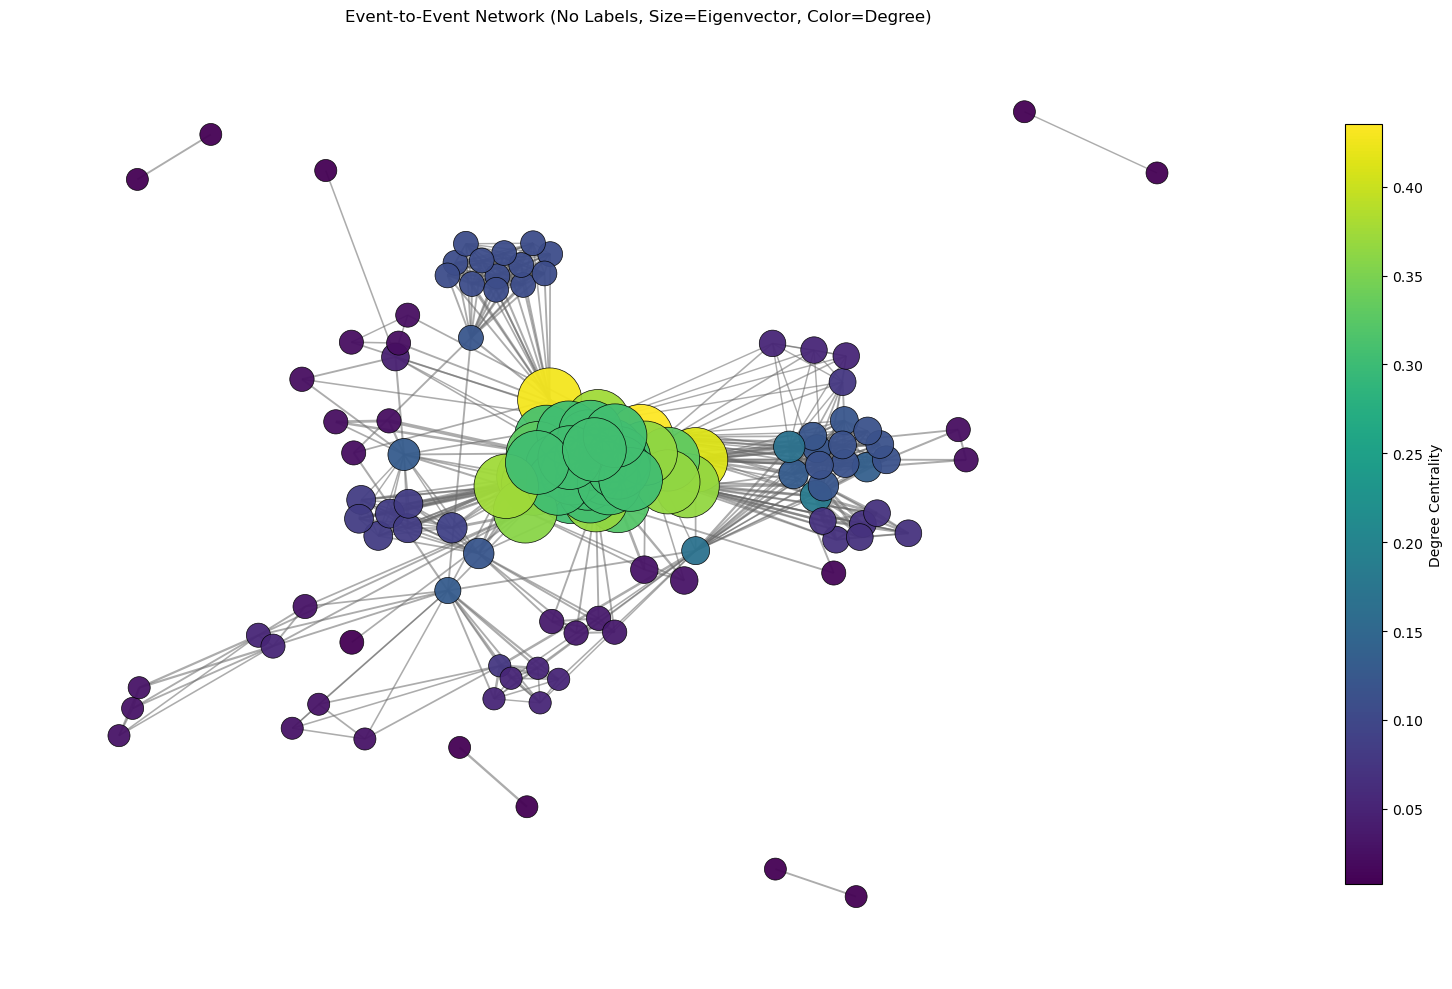

In [43]:
# Visualize weighted event graph (state_g)
fig, ax = plt.subplots(figsize=(16, 10))

if state_g.number_of_nodes() == 0:
    print("state_g is empty. Run Cell 4 first to build the graph.")
else:
    pos = nx.spring_layout(state_g, seed=42, k=0.45)

    edge_weights = [state_g[u][v].get('weight', 1) for u, v in state_g.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [0.8 + (w / max_w) * 4 for w in edge_weights]

    # Size by eigenvector centrality, color by degree centrality
    degree_centrality = nx.degree_centrality(state_g)
    eigenvector_centrality = nx.eigenvector_centrality(state_g, max_iter=1000)

    node_sizes = [250 + 12000 * eigenvector_centrality[n] for n in state_g.nodes()]
    node_colors = [degree_centrality[n] for n in state_g.nodes()]

    nx.draw_networkx_nodes(
        state_g,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.viridis,
        edgecolors='black',
        linewidths=0.5,
        alpha=0.95,
        ax=ax
    )
    nx.draw_networkx_edges(
        state_g,
        pos,
        width=edge_widths,
        edge_color='dimgray',
        alpha=0.55,
        ax=ax
    )

    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.viridis,
        norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
    )
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Degree Centrality', shrink=0.8)

    ax.set_title('Event-to-Event Network (No Labels, Size=Eigenvector, Color=Degree)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Random Forest Classifcation

Utilizing two different data sets to understand physical attributes (height), state origin, and age of athlete at event to classify which features are most important to medaling. State has the highest importance out of all the features, leading to "nurture" having a higher importance than "nature". 

Full distribution:
medaled
0    1572
1     157
Name: count, dtype: int64

Total samples: 127
Medalists:     115
Non-medalists: 12

Classification report:
              precision    recall  f1-score   support

    No Medal       0.20      0.50      0.29         2
       Medal       0.95      0.83      0.89        24

    accuracy                           0.81        26
   macro avg       0.58      0.67      0.59        26
weighted avg       0.89      0.81      0.84        26



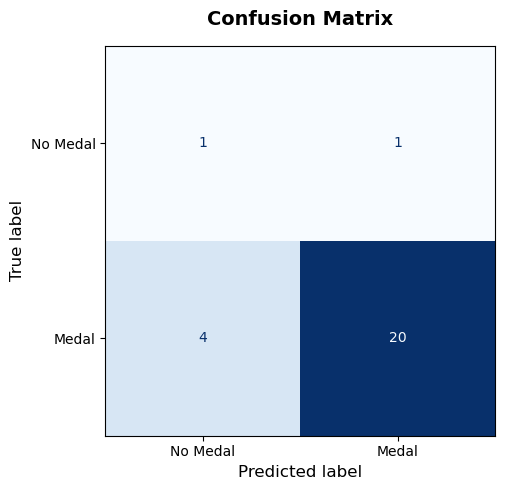


Feature importances:


state     0.386492
age       0.361651
height    0.251857
dtype: float64

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
# Identify US athletes with data on height, state, age
usa_names = DATA_DICT['athlete_profiles']['athlete_full_name'].unique()
olympic_athletes = DATA_DICT['olympic_athletes'].copy()
usa_all = olympic_athletes[olympic_athletes['athlete_full_name'].isin(usa_names)].copy()

# Calculate age at first game based on birth year
usa_all['game_year'] = usa_all['first_game'].str.extract(r'(\d{4})').astype(float)
usa_all['age'] = usa_all['game_year'] - usa_all['athlete_year_birth']

# Data Preprocessing
profiles = DATA_DICT['athlete_profiles'].copy()
profiles['height'] = profiles['height'].apply(parse_height_to_feet)
profiles['height'] = pd.to_numeric(profiles['height'], errors='coerce')
profiles['city'], profiles['state'] = zip(
    *profiles['hometown'].apply(extract_city_state)
)

usa_all = pd.merge(
    usa_all,
    profiles[['athlete_full_name', 'height', 'state']],
    on='athlete_full_name',
    how='left'
)

# Identify Medalists
usa_all['medaled'] = usa_all['athlete_full_name'].isin(
    athlete_bio_medals['athlete_full_name']
).astype(int)

print("Full distribution:")
print(usa_all['medaled'].value_counts())

model_df = usa_all[['age', 'height', 'state', 'medaled']].dropna().copy()
model_df['state_encoded'] = LabelEncoder().fit_transform(model_df['state'])

X = model_df[['age', 'height', 'state_encoded']].astype('float64')
y = model_df['medaled']

print(f"\nTotal samples: {len(y)}")
print(f"Medalists:     {y.sum()}")
print(f"Non-medalists: {(y==0).sum()}")

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE due to data skewed more toward medalists 
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_res, y_train_res)

# Classification Report and Accuracy Results 
y_pred = rf.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['No Medal', 'Medal']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Medal', 'Medal'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
plt.tight_layout()
plt.show()

# Feature importances 
print("\nFeature importances:")
feature_importances = pd.Series(
    rf.feature_importances_,
    index=['age', 'height', 'state']
).sort_values(ascending=False)
display(feature_importances)
feature_importances.to_csv(os.path.join(VIS_DIR,'feature_importances.csv'),
                           index=True,
                           header=['feature_importance'])